In [6]:
!pip3 install pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 40.7 MB/s eta 0:00:00


In [11]:
import os
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pytorch_lightning as pl
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import MNIST

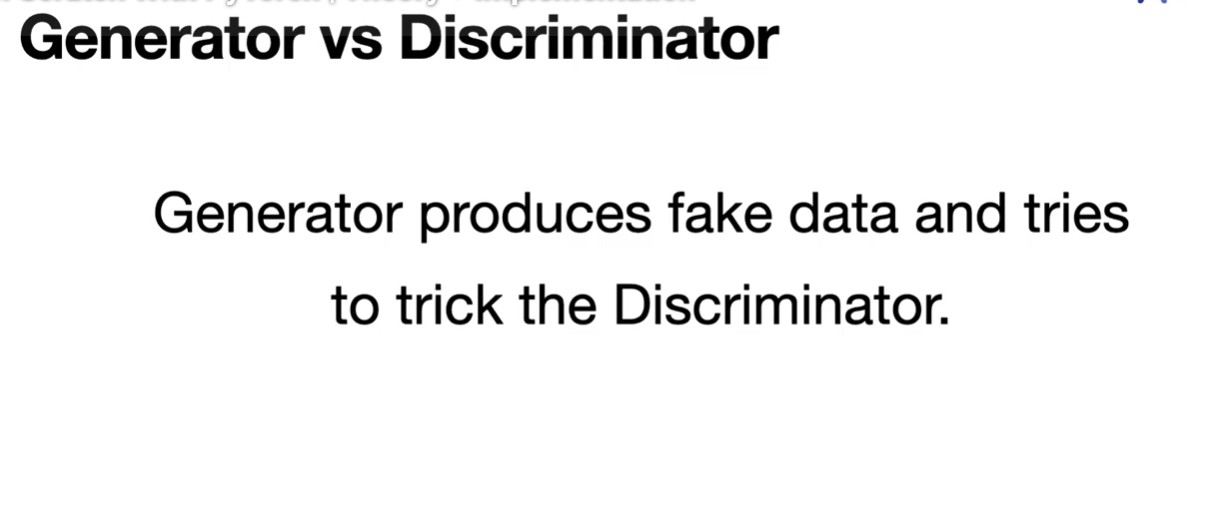

In [12]:
from PIL import Image
Image.open(r'/content/Generator_vs_discriminator.jpg')

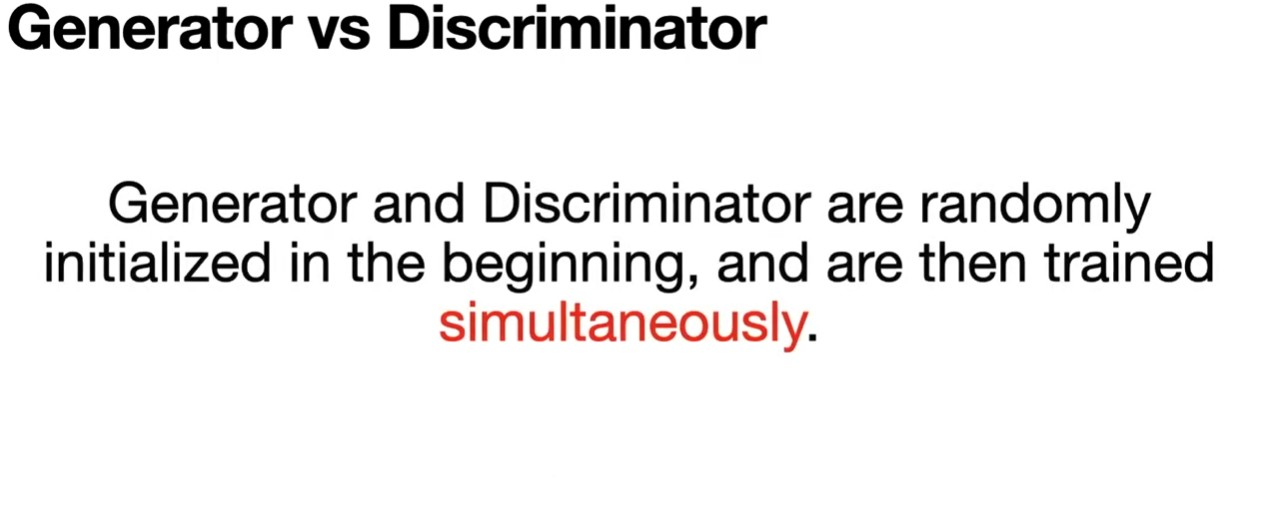

In [13]:
from PIL import Image
Image.open(r'/content/Generator_vs_discriminator_1.jpg')

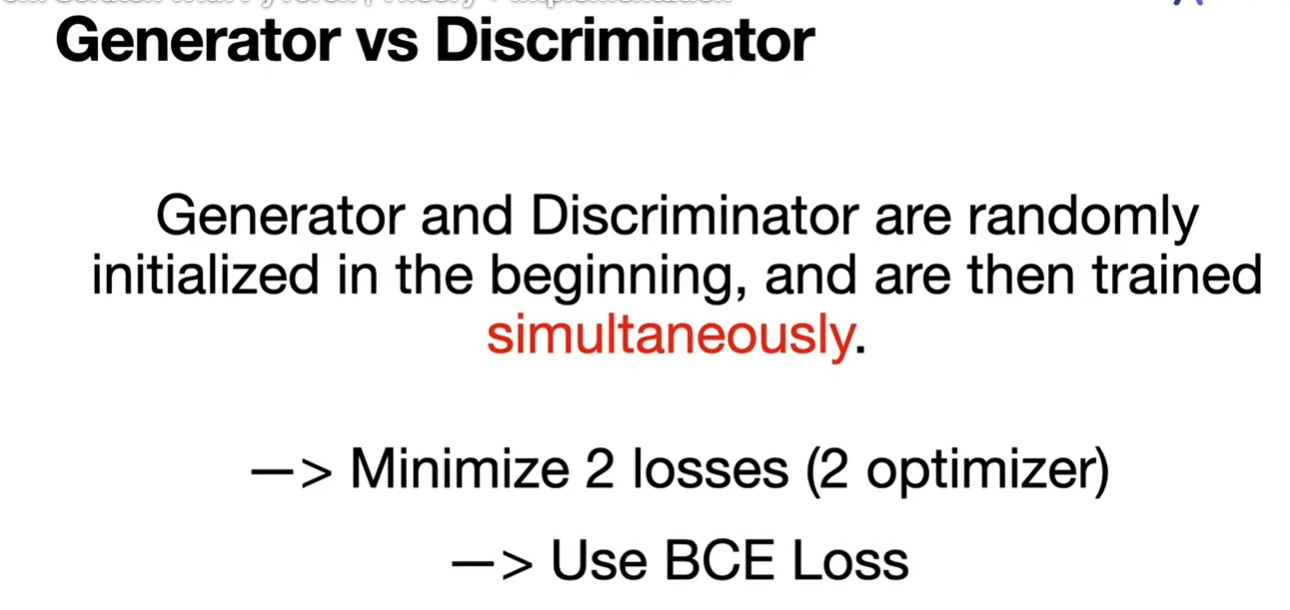

In [14]:
from PIL import Image
Image.open(r'/content/Generator_vs_discriminator_2.jpg')

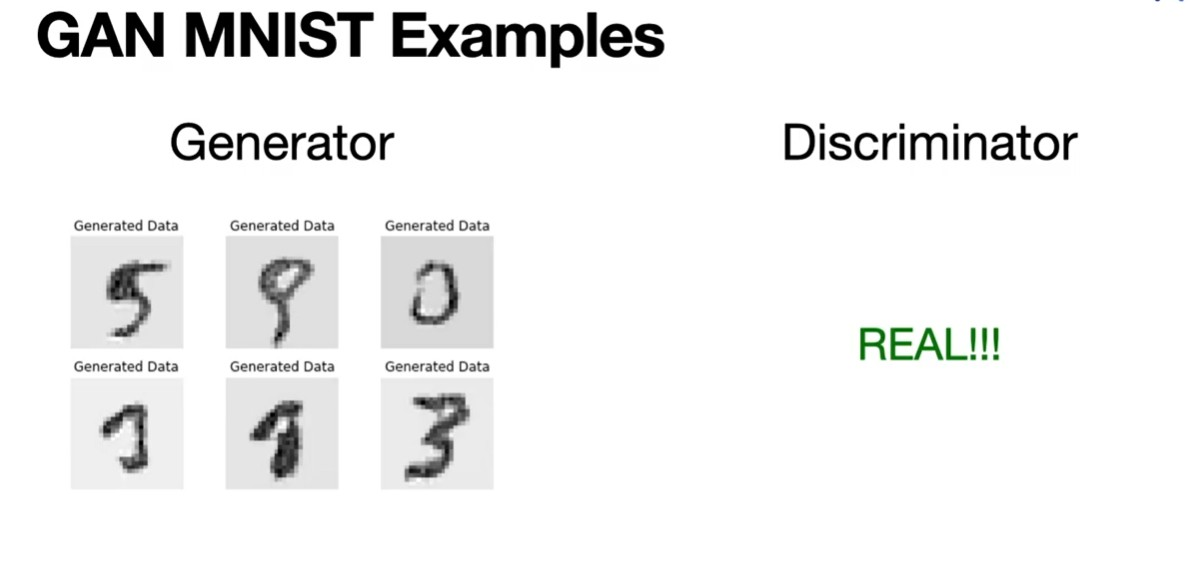

In [15]:
from PIL import Image
Image.open(r'/content/Generator_vs_discriminator_3.jpg')

In [7]:
random_seed=42
torch.manual_seed(random_seed)

In [9]:
import os
BATCH_SIZE=128
AVAIL_GPUS=min(1,torch.cuda.device_count())
NUM_WORKERS=int(os.cpu_count()/2)
NUM_WORKERS

1

In [12]:
class MNISTDataModule(pl.LightningDataModule):
  def __init__(self,data_dir='./',batch_size=BATCH_SIZE):
    super().__init__()
    self.data_dir=data_dir
    self.batch_size=batch_size
    self.transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,),(0.3081,))
    ])
    def prepare_data(self):
      MNIST(self.data_dir,train=True,download=True)
      MNIST(self.data_dir,train=False,download=True)
    def setup(self,stage=None):
      if stage == 'fit' or stage is None:
        mnist_full=MNIST(self.data_dir,train=True,transform=self.transform)
        self.mnist_train,self.mnist_val=torch.utils.data.random_split(mnist_full,[55000,5000])
    def train_dataloader(self):
      return DataLoader(self.mnist_train,batch_size=self.batch_size,num_workers=NUM_WORKERS)
    def val_datalaoder(self):
      return DataLoader(self.mnist_val,batch_size=self.batch_size,num_workers=NUM_WORKERS)
    def test_dataloader(self):
      return DataLoader(self.mnist_test,batch_size=self.batch_size,num_workers=NUM_WORKERS)


In [13]:
## detective fake or no fake ->1 ouput[1,0]
class Discriminator(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1=nn.Conv2d(1,10,kernel_size=5)
    self.conv2=nn.Conv2d(10,20,kernel_size=5)
    self.conv2_drop=nn.Dropout2d()
    self.fc1=nn.Linear(320,50)
    self.fc2=nn.Linear(50,10)
  def forward(self,x):
    x=F.relu(F.max_pool2d(self.conv1(x),2))
    x=F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)),2))
    ## flatten the tensor so it can be fed into the FC Layers
    x=x.view(-1,320)
    x=F.relu(self.fc1(x))
    x=F.dropout(x,training=self.training)
    x=self.fc2(x)
    return torch.sigmmoid(x)

In [6]:
# class LitMNIST(pl.LightningModule):
#   def __init__(self,data_dir='./',hidden_size=64,learning_rate=2e-4):
#     super().__init__()
#     self.data_dir=data_dir
#     self.hidden_size=hidden_size
#     self.learning_rate=learning_rate
#   def prepare_data(self) -> None:
#     MNIST(self.data_dir,train=True,download=True)
#     MNIST(self.data_dir,train=False,download=True)
#   def setup(self,stage=None):
#     if stage == 'fit' or stage is None:
#       mnist_full=MNIST(self.data_dir,train=True,transform=transforms.ToTensor())
#   def train_dataloader(self):
#     mnist_full=MNIST(self.data_dir,train=True,transform=transforms.ToTensor())
#   def test_dataloader(self):
#     pass


In [ ]:
## Generate Fake Data

In [14]:
class Generator(nn.Module):
  def __init__(self,latent_dim):
    super().__init__()
    self.lin1=nn.Linear(latent_dim,7*7*64) ##[n,256,7,7]
    self.ct1=nn.Conv2d(128,128,3,stride=1,padding=1) #[n,64,16,16]
    self.ct2=nn.ConvTranspose2d(32,16,4,stride=2,padding=1) #[n,16,34,34]
    self.conv=nn.Conv2d(16,1,kernel_size=7) ##[n,1,28,28]
  def forward(self,x):
    ##pass latent space input into a linear layer and reshape
    x=F.relu(self.lin1(x))
    x=F.relu(x)
    x=x.view(-1,64,7,7)
    ## upsample(transposed conv) 16*16(64 feature maps)
    x=F.relu(self.ct1(x))
    x=F.relu(self.ct2(x))
    return x

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
import pytorch_lightning as pl

class GeneratorNet(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28*28),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


class DiscriminatorNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


class GAN(pl.LightningModule):
    def __init__(self, latent_dim=100, lr=0.0002):
        super().__init__()
        self.save_hyperparameters()
        self.generator = GeneratorNet(latent_dim)
        self.discriminator = DiscriminatorNet()
        self.validation_z = torch.randn(64, latent_dim)
        self.automatic_optimization = False   # manual optimization

    def adversarial_loss(self, y_hat, y):
        return F.binary_cross_entropy(y_hat, y)

    def forward(self, z):
        return self.generator(z)

    def training_step(self, batch, batch_idx):
        opt_g, opt_d = self.optimizers()
        real_imgs, _ = batch
        batch_size = real_imgs.size(0)

        # -----------------
        # Train Discriminator
        # -----------------
        z = torch.randn(batch_size, self.hparams.latent_dim, device=self.device)
        fake_imgs = self(z).detach()

        real_loss = self.adversarial_loss(self.discriminator(real_imgs), torch.ones(batch_size, 1, device=self.device))
        fake_loss = self.adversarial_loss(self.discriminator(fake_imgs), torch.zeros(batch_size, 1, device=self.device))
        d_loss = (real_loss + fake_loss) / 2

        opt_d.zero_grad()
        self.manual_backward(d_loss)
        opt_d.step()

        # -----------------
        # Train Generator
        # -----------------
        z = torch.randn(batch_size, self.hparams.latent_dim, device=self.device)
        fake_imgs = self(z)
        g_loss = self.adversarial_loss(self.discriminator(fake_imgs), torch.ones(batch_size, 1, device=self.device))

        opt_g.zero_grad()
        self.manual_backward(g_loss)
        opt_g.step()

        self.log("d_loss", d_loss, prog_bar=True)
        self.log("g_loss", g_loss, prog_bar=True)

    def configure_optimizers(self):
        lr = self.hparams.lr
        opt_g = torch.optim.Adam(self.generator.parameters(), lr=lr, betas=(0.5, 0.999))
        opt_d = torch.optim.Adam(self.discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
        return [opt_g, opt_d]

    def plot_imgs(self):
        z = self.validation_z.type_as(self.generator.net[0].weight)
        sample_imgs = self(z)
        grid = torchvision.utils.make_grid(sample_imgs, normalize=True)
        plt.figure(figsize=(10,10))
        plt.imshow(grid.permute(1,2,0).cpu().detach().numpy())
        plt.axis("off")
        plt.show()

    def on_epoch_end(self):
        self.plot_imgs()


In [18]:
import pytorch_lightning as pl
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

class MNISTDataModule(pl.LightningDataModule):
    def __init__(self, data_dir="./", batch_size=64):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

    def prepare_data(self):
        # download only
        datasets.MNIST(self.data_dir, train=True, download=True)
        datasets.MNIST(self.data_dir, train=False, download=True)

    def setup(self, stage=None):
        # assign train/val/test datasets
        if stage == "fit" or stage is None:
            self.mnist_train = datasets.MNIST(self.data_dir, train=True, transform=self.transform)
            self.mnist_val = datasets.MNIST(self.data_dir, train=False, transform=self.transform)

    def train_dataloader(self):
        return DataLoader(self.mnist_train, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.mnist_val, batch_size=self.batch_size)


In [19]:
dm=MNISTDataModule()
model=GAN(latent_dim=100)
trainer=pl.Trainer(max_epochs=3)
trainer.fit(model, datamodule=dm)

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.85MB/s]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | generator     | GeneratorNet     |

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.


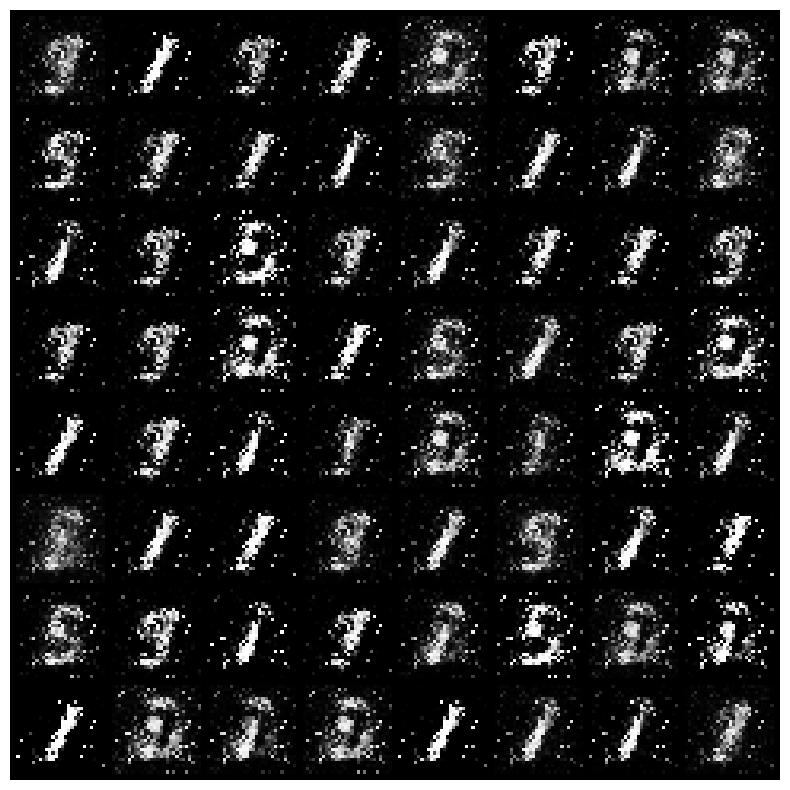

In [20]:
model.plot_imgs()

In [23]:
trainer=pl.Trainer(max_epochs=3)
trainer.fit(model, datamodule=dm)

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
INFO:pytorch_lightning.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | generator     | GeneratorNet     | 559 K  | train
1 | discriminator | DiscriminatorNet | 533 K  | train
-----------------------------------------------------------
1.1 M     Trainable params
0         Non-trainable params
1.1 M     Total params


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
